Purpose: Look at flowering & fruiting data Kylie Hays collected from iNaturalist for all three *Yucca* species.<br>
Author: Anna Pardo<br>
Date initiated: May 28, 2026

In [52]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from datetime import datetime
import matplotlib.dates as mdates

In [12]:
# load iNaturalist data
ygin = pd.read_csv("./inat_data_Yg.csv",sep=",",header="infer")
ygin = ygin.rename(columns={"Unnamed: 4":"Fruit"})
ygin["Species"] = "Y. gloriosa"
ygin.head()

,Species,Date,Location,Flowering,Fruit,Budding,Lat/Lon,Link,Notes
0,Y. gloriosa,9/13/2008,"Georgetown County, SC",Yes,No,Yes,"33.551738, -79.018066",https://www.inaturalist.org/observations/85415489,NaN
1,Y. gloriosa,11/4/2011,"Sullivan's Island, SC",Yes,No,No,"32.7605183951, -79.8323464394",https://www.inaturalist.org/observations/14347...,NaN
2,Y. gloriosa,4/29/2015,"Beaufort County, SC",Yes,No,No,"32.403785348, -80.4281096359",https://www.inaturalist.org/observations/14647...,NaN
3,Y. gloriosa,8/8/2015,"Hilton Head Island, SC",Yes,No,No,"32.2520833333, -80.7012555556",https://www.inaturalist.org/observations/7368593,NaN
4,Y. gloriosa,10/25/2016,"Hilton Head Island, SC",Yes,No,Yes,"32.2063055556, -80.6819527778",https://www.inaturalist.org/observations/7425346,NaN


In [10]:
yain = pd.read_csv("./inat_data_Ya.csv",sep=",",header="infer")
yain.head()

,Species,Date,Location,Flowering,Fruit,Budding,Lat/Lon,Link,Notes
0,Y. aloifolia,5/26/2010,"St. Johns County, FL",Yes,No,No,"30.0293864747, -81.3362822722",https://www.inaturalist.org/observations/17208...,NaN
1,Y. aloifolia,5/9/2013,"Bradenton, FL",Yes,No,Yes,"27.521692, -82.643475",https://www.inaturalist.org/observations/260901,NaN
2,Y. aloifolia,5/11/2013,"Punta Gorda, FL",Yes,No,Yes,"26.915702, -82.091372",https://www.inaturalist.org/observations/264005,NaN
3,Y. aloifolia,4/24/2014,"Palma Sola, FL",Yes,No,Yes,"27.51226, -82.632043",https://www.inaturalist.org/observations/886700,NaN
4,Y. aloifolia,4/25/2014,"Bradenton, FL",No,No,Yes,"27.4650166667, -82.6471166667",https://www.inaturalist.org/observations/682210,NaN


In [11]:
yfin = pd.read_csv("./inat_data_Yf.csv",sep=",",header="infer")
yfin.head()

,Species,Date,Location,Flowering,Fruit,Budding,Lat/Lon,Link,Notes
0,Y. filamentosa,5/2/2011,"Duval, FL",Yes,No,Yes,"30.4369433333, -81.4129033333",https://www.inaturalist.org/observations/86795741,NaN
1,Y. filamentosa,5/30/2013,"Richland County, SC",Yes,No,Yes,"33.7918510001, -80.7490487024",https://www.inaturalist.org/observations/14444...,NaN
2,Y. filamentosa,5/10/2015,"Citrus County, FL",Yes,No,Yes,"28.7784954008, -82.5829182456",https://www.inaturalist.org/observations/40839097,NaN
3,Y. filamentosa,6/13/2016,"Okaloosa County, FL",No,Yes,No,"30.384673, -86.443995",https://www.inaturalist.org/observations/3534235,NaN
4,Y. filamentosa,5/7/2017,"Sullivan's Island, SC",Yes,No,No,"32.7583351135, -79.8561096191",https://www.inaturalist.org/observations/6258820,NaN


In [14]:
yfin["Species"].unique()

array(['Y. filamentosa'], dtype=object)

In [15]:
# stick all data together
inat = pd.concat([yain,yfin,ygin])

In [18]:
inat["Flowering"].fillna("No",inplace=True)
inat["Flowering"] = inat["Flowering"].map({"Yes":"Yes","No":"No","No ":"No"})
inat["Flowering"].unique()

array(['Yes', 'No'], dtype=object)

In [20]:
inat["Fruit"].fillna("No",inplace=True)
inat["Fruit"].unique()

array(['No', 'Yes'], dtype=object)

In [22]:
inat["Budding"].fillna("No",inplace=True)
inat["Budding"].unique()

array(['No', 'Yes'], dtype=object)

In [23]:
# split lat & long into separate columns
inat["Latitude"] = inat["Lat/Lon"].str.split(",").str[0]
inat["Longitude"] = inat["Lat/Lon"].str.split(", ").str[1]
inat.head()

,Species,Date,Location,Flowering,Fruit,Budding,Lat/Lon,Link,Notes,Latitude,Longitude
0,Y. aloifolia,5/26/2010,"St. Johns County, FL",Yes,No,No,"30.0293864747, -81.3362822722",https://www.inaturalist.org/observations/17208...,NaN,30.0293864747,-81.3362822722
1,Y. aloifolia,5/9/2013,"Bradenton, FL",Yes,No,Yes,"27.521692, -82.643475",https://www.inaturalist.org/observations/260901,NaN,27.521692,-82.643475
2,Y. aloifolia,5/11/2013,"Punta Gorda, FL",Yes,No,Yes,"26.915702, -82.091372",https://www.inaturalist.org/observations/264005,NaN,26.915702,-82.091372
3,Y. aloifolia,4/24/2014,"Palma Sola, FL",Yes,No,Yes,"27.51226, -82.632043",https://www.inaturalist.org/observations/886700,NaN,27.51226,-82.632043
4,Y. aloifolia,4/25/2014,"Bradenton, FL",No,No,Yes,"27.4650166667, -82.6471166667",https://www.inaturalist.org/observations/682210,NaN,27.4650166667,-82.6471166667


In [62]:
# make a GeoDataFrame 
df = inat[["Species","Date","Flowering","Fruit","Budding","Latitude","Longitude"]]
gdf = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df.Longitude,df.Latitude),crs="EPSG:4326")

In [63]:
gdf.head()

,Species,Date,Flowering,Fruit,Budding,Latitude,Longitude,geometry
0,Y. aloifolia,5/26/2010,Yes,No,No,30.0293864747,-81.3362822722,POINT (-81.33628 30.02939)
1,Y. aloifolia,5/9/2013,Yes,No,Yes,27.521692,-82.643475,POINT (-82.64347 27.52169)
2,Y. aloifolia,5/11/2013,Yes,No,Yes,26.915702,-82.091372,POINT (-82.09137 26.91570)
3,Y. aloifolia,4/24/2014,Yes,No,Yes,27.51226,-82.632043,POINT (-82.63204 27.51226)
4,Y. aloifolia,4/25/2014,No,No,Yes,27.4650166667,-82.6471166667,POINT (-82.64712 27.46502)


In [26]:
# load US state borders map
kml_file = "./cb_2018_us_state_500k/cb_2018_us_state_500k.kml"

states = gpd.read_file(
    kml_file,
    driver="KML",
    engine="pyogrio"
)

In [64]:
# convert Date column of gdf to a date obj instead of str
gdf["datetime"] = pd.to_datetime(gdf["Date"])
gdf.head()

,Species,Date,Flowering,Fruit,Budding,Latitude,Longitude,geometry,datetime
0,Y. aloifolia,5/26/2010,Yes,No,No,30.0293864747,-81.3362822722,POINT (-81.33628 30.02939),2010-05-26
1,Y. aloifolia,5/9/2013,Yes,No,Yes,27.521692,-82.643475,POINT (-82.64347 27.52169),2013-05-09
2,Y. aloifolia,5/11/2013,Yes,No,Yes,26.915702,-82.091372,POINT (-82.09137 26.91570),2013-05-11
3,Y. aloifolia,4/24/2014,Yes,No,Yes,27.51226,-82.632043,POINT (-82.63204 27.51226),2014-04-24
4,Y. aloifolia,4/25/2014,No,No,Yes,27.4650166667,-82.6471166667,POINT (-82.64712 27.46502),2014-04-25


In [65]:
# extract month & day information (don't care about year, for coloring purposes)
gdf['month'] = gdf['datetime'].dt.month
gdf['day'] = gdf['datetime'].dt.day

In [68]:
# create day-of-year information with dummy year (care about seasonal phenology for this, not year information)
gdf["plot_date"] = pd.to_datetime({
    "year": 2000,   # arbitrary leap-safe reference year
    "month": gdf["month"],
    "day": gdf["day"]
})

In [70]:
# convert to matplotlib numeric dates
gdf["plot_num"] = mdates.date2num(gdf["plot_date"])

In [71]:
# subset to flowering=Yes, fruit=Yes, and budding=Yes (separately)
flower = gdf[gdf["Flowering"]=="Yes"]
fruit = gdf[gdf["Fruit"]=="Yes"]
bud = gdf[gdf["Budding"]=="Yes"]

In [72]:
flower.head()

,Species,Date,Flowering,Fruit,Budding,Latitude,Longitude,geometry,datetime,month,day,plot_date,plot_num
0,Y. aloifolia,5/26/2010,Yes,No,No,30.0293864747,-81.3362822722,POINT (-81.33628 30.02939),2010-05-26,5,26,2000-05-26,11103.0
1,Y. aloifolia,5/9/2013,Yes,No,Yes,27.521692,-82.643475,POINT (-82.64347 27.52169),2013-05-09,5,9,2000-05-09,11086.0
2,Y. aloifolia,5/11/2013,Yes,No,Yes,26.915702,-82.091372,POINT (-82.09137 26.91570),2013-05-11,5,11,2000-05-11,11088.0
3,Y. aloifolia,4/24/2014,Yes,No,Yes,27.51226,-82.632043,POINT (-82.63204 27.51226),2014-04-24,4,24,2000-04-24,11071.0
5,Y. aloifolia,5/9/2015,Yes,No,Yes,30.0744327507,-84.1802364411,POINT (-84.18024 30.07443),2015-05-09,5,9,2000-05-09,11086.0


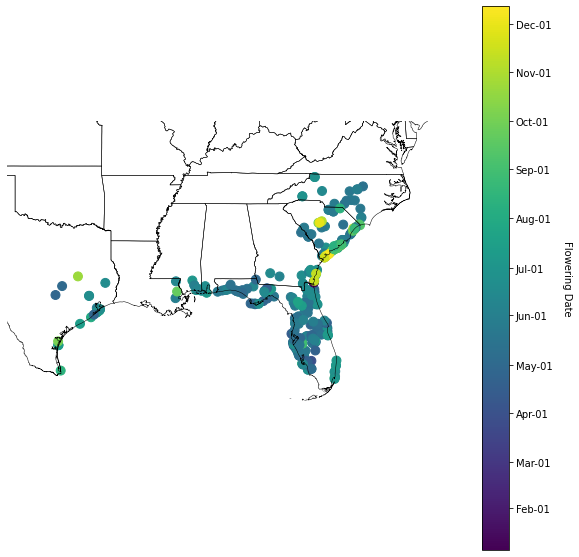

In [74]:
fig, ax = plt.subplots(figsize=(10,10))

states.boundary.plot(ax=ax, color="black", linewidth=0.5)

flower.plot(
    ax=ax,
    column="plot_num",
    cmap="viridis",
    markersize=80,
    #alpha=0.7,
    legend=True,
    legend_kwds = {"label":""}
)

# access colorbar
cax = fig.axes[-1]

# show only month/day labels
locator = mdates.MonthLocator()
formatter = mdates.DateFormatter('%b-%d')

cax.yaxis.set_major_locator(locator)
cax.yaxis.set_major_formatter(formatter)

cax.set_ylabel(
    "Flowering Date",
    rotation=270,
    labelpad=20
)

xmin, ymin, xmax, ymax = gdf.total_bounds

# padding in degrees
xpad = 3
ypad = 3

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.set_axis_off()

In [75]:
# change marker styles by species
marker_dict = {
    "Y. aloifolia": "o",
    "Y. filamentosa": "^",
    "Y. gloriosa": "s"
}

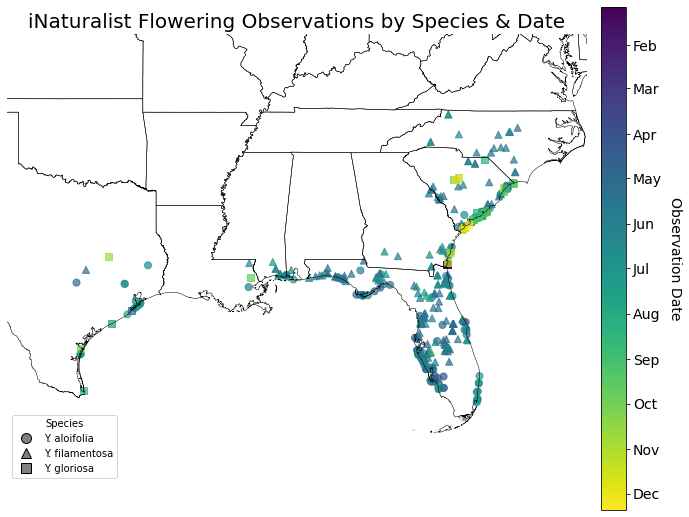

In [88]:
norm = mcolors.Normalize(
    vmin=flower["plot_num"].min(),
    vmax=flower["plot_num"].max()
)

fig, ax = plt.subplots(figsize=(10,10))

states.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

# plot each species separately
for species, marker in marker_dict.items():

    sub = flower[flower["Species"] == species]

    sub.plot(
        ax=ax,
        column="plot_num",
        cmap="viridis",
        norm=norm,
        marker=marker,
        markersize=50,
        alpha=0.7,
        legend=False
    )

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=norm
)

cbar = fig.colorbar(sm, ax=ax, shrink=0.72, pad=0.02)
cbar.ax.invert_yaxis()

# monthly ticks in chronological order
tick_dates = pd.date_range(
    flower["plot_date"].min().floor("D"),
    flower["plot_date"].max().ceil("D"),
    freq="MS"
)

tick_locs = mdates.date2num(tick_dates)

cbar.set_ticks(tick_locs)
cbar.set_ticklabels(
    [d.strftime("%b") for d in tick_dates],
    fontsize=14
)

cbar.set_label(
    "Observation Date",
    rotation=270,
    labelpad=20,
    fontsize=14
)

handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=10,
        label=species
    )
    for species, marker in marker_dict.items()
]

ax.legend(
    handles=handles,
    title="Species",
    loc="lower left"
)

xmin, ymin, xmax, ymax = flower.total_bounds

ax.set_xlim(xmin - 3, xmax + 3)
ax.set_ylim(ymin - 3, ymax + 3)

ax.set_axis_off()

plt.title("iNaturalist Flowering Observations by Species & Date",fontsize=20)
plt.tight_layout()

plt.savefig("./inat_flowering_map.png",dpi=300,bbox_inches="tight")
plt.savefig("./inat_flowering_map.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./inat_flowering_map.svg",dpi=300,bbox_inches="tight")

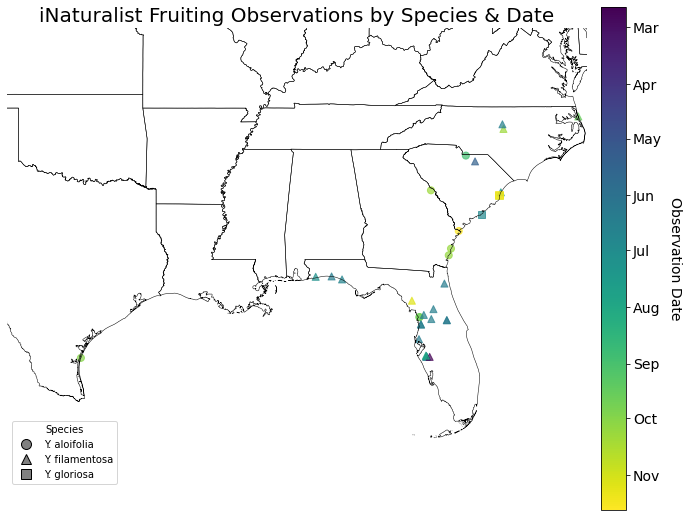

In [90]:
norm = mcolors.Normalize(
    vmin=fruit["plot_num"].min(),
    vmax=fruit["plot_num"].max()
)

fig, ax = plt.subplots(figsize=(10,10))

states.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

# plot each species separately
for species, marker in marker_dict.items():

    sub = fruit[fruit["Species"] == species]

    sub.plot(
        ax=ax,
        column="plot_num",
        cmap="viridis",
        norm=norm,
        marker=marker,
        markersize=50,
        alpha=0.7,
        legend=False
    )

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=norm
)

cbar = fig.colorbar(sm, ax=ax, shrink=0.72, pad=0.02)
cbar.ax.invert_yaxis()

# monthly ticks in chronological order
tick_dates = pd.date_range(
    fruit["plot_date"].min().floor("D"),
    fruit["plot_date"].max().ceil("D"),
    freq="MS"
)

tick_locs = mdates.date2num(tick_dates)

cbar.set_ticks(tick_locs)
cbar.set_ticklabels(
    [d.strftime("%b") for d in tick_dates],
    fontsize=14
)

cbar.set_label(
    "Observation Date",
    rotation=270,
    labelpad=20,
    fontsize=14
)

handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=10,
        label=species
    )
    for species, marker in marker_dict.items()
]

ax.legend(
    handles=handles,
    title="Species",
    loc="lower left"
)

xmin, ymin, xmax, ymax = flower.total_bounds

ax.set_xlim(xmin - 3, xmax + 3)
ax.set_ylim(ymin - 3, ymax + 3)

ax.set_axis_off()

plt.title("iNaturalist Fruiting Observations by Species & Date",fontsize=20)
plt.tight_layout()

plt.savefig("./inat_fruiting_map.png",dpi=300,bbox_inches="tight")
plt.savefig("./inat_fruiting_map.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./inat_fruiting_map.svg",dpi=300,bbox_inches="tight")

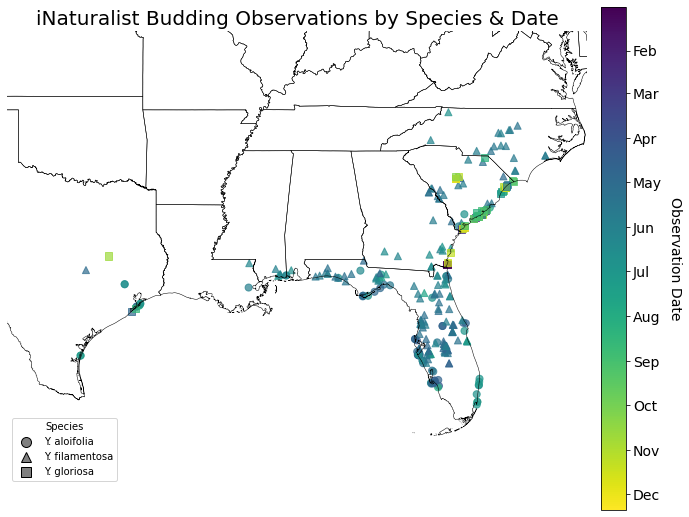

In [91]:
norm = mcolors.Normalize(
    vmin=bud["plot_num"].min(),
    vmax=bud["plot_num"].max()
)

fig, ax = plt.subplots(figsize=(10,10))

states.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

# plot each species separately
for species, marker in marker_dict.items():

    sub = bud[bud["Species"] == species]

    sub.plot(
        ax=ax,
        column="plot_num",
        cmap="viridis",
        norm=norm,
        marker=marker,
        markersize=50,
        alpha=0.7,
        legend=False
    )

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=norm
)

cbar = fig.colorbar(sm, ax=ax, shrink=0.72, pad=0.02)
cbar.ax.invert_yaxis()

# monthly ticks in chronological order
tick_dates = pd.date_range(
    bud["plot_date"].min().floor("D"),
    bud["plot_date"].max().ceil("D"),
    freq="MS"
)

tick_locs = mdates.date2num(tick_dates)

cbar.set_ticks(tick_locs)
cbar.set_ticklabels(
    [d.strftime("%b") for d in tick_dates],
    fontsize=14
)

cbar.set_label(
    "Observation Date",
    rotation=270,
    labelpad=20,
    fontsize=14
)

handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="",
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=10,
        label=species
    )
    for species, marker in marker_dict.items()
]

ax.legend(
    handles=handles,
    title="Species",
    loc="lower left"
)

xmin, ymin, xmax, ymax = flower.total_bounds

ax.set_xlim(xmin - 3, xmax + 3)
ax.set_ylim(ymin - 3, ymax + 3)

ax.set_axis_off()

plt.title("iNaturalist Budding Observations by Species & Date",fontsize=20)
plt.tight_layout()

plt.savefig("./inat_budding_map.png",dpi=300,bbox_inches="tight")
plt.savefig("./inat_budding_map.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./inat_budding_map.svg",dpi=300,bbox_inches="tight")

In [94]:
ygin[ygin["Fruit"]=="Yes"].to_csv("./iNat_Yg_fruitobs.csv",sep=",",header=True,index=False)

In [ ]:
# note: Karolina says the fruiting Yg are actually Ya (upon review of iNat photos)